In [ ]:
# run directory 생성

from datetime import datetime
from pathlib import Path

def create_run_dir(
    experiment_name, 
    root=r"C:\Users\limux\Documents\1. Projects\KANT Private LLM Infra Engineer\kant-llm-engineer-main\step1_llm-foundations\ch03_deep-learning-basic"):

    # 현재 시각을 문자열로 변환 → 실행마다 고유한 폴더명 확보용
    # %Y=연 %m=월 %d=일 / %H=시 %M=분 %S=초 / %f=마이크로초(중복 방지 목적)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S_%f")

    # 루트 경로 아래에 "타임스탬프_실험이름" 형태의 실행 폴더 경로 구성
    run_dir = Path(root) / f"{timestamp}_{experiment_name}"

    # 체크포인트 저장용 하위 폴더 생성
    # parents=True → 중간 경로(runs, run_dir)까지 한 번에 생성
    # exist_ok=False → 이미 존재하면 에러 발생시켜 덮어쓰기 방지
    (run_dir / "checkpoints").mkdir(parents=True, exist_ok=False)

    # 그래프/시각화 저장용 하위 폴더 생성 (상위 폴더는 위에서 이미 생성됨)
    (run_dir / "plots").mkdir()

    # 생성된 실행 폴더 경로 반환
    return run_dir


# 실험 이름을 지정해 실행 폴더 생성
run_dir = create_run_dir("mlp_baseline")

# 생성된 폴더 경로 출력
print(f"실험 폴더: {run_dir}")

실험 폴더: C:\Users\limux\Documents\1. Projects\KANT Private LLM Infra Engineer\kant-llm-engineer-main\step1_llm-foundations\ch03_deep-learning-basic\20260901_102210_331236_mlp_baseline


In [ ]:
# config.json 저장하기

import json

config = {
    "model_name": "SimpleMLP",
    "num_samples": 600,
    "input_dim": 4,
    "hidden_dim": 32,
    "num_classes": 3,
    "learning_rate": 0.01,
    "batch_size": 32,
    "epochs": 3,
    "seed": 42,
    "device": "cuda",
}

config_path = run_dir / "config.json"

with open(config_path, "w", encoding="utf-8") as file:
    json.dump(config, file, ensure_ascii=False, indent=2)

print(f"config 저장: {config_path}")

config 저장: C:\Users\limux\Documents\1. Projects\KANT Private LLM Infra Engineer\kant-llm-engineer-main\step1_llm-foundations\ch03_deep-learning-basic\20260901_102210_331236_mlp_baseline\config.json


In [ ]:
# 3 epoch의 실험 준비

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split

torch.manual_seed(config["seed"])

# (600, 4)
X = torch.randn(config["num_samples"], config["input_dim"])
true_W = torch.tensor([
    [1.0, -1.0, 0.5],
    [0.5, 1.5, -1.0],
    [-1.0, 0.5, 1.0],
    [1.0, 0.2, -0.5],
])
y = (X @ true_W).argmax(dim=1)

dataset = TensorDataset(X, y)
train_size = int(len(dataset) * 0.8)    # 480
val_size = len(dataset) - train_size    # 120

split_generator = torch.Generator().manual_seed(config["seed"])
train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator = split_generator,
)

loader_generator = torch.Generator().manual_seed(config["seed"])
train_loader = DataLoader(
    train_dataset,
    batch_size = config["batch_size"],  # 32
    shuffle = True,
    generator = loader_generator,
)
val_loader = DataLoader(val_dataset, batch_size = config["batch_size"], shuffle=False)

In [13]:
# 모델과 학습, 검증 함수를 정의

class SimpleMLP(nn.Module):
    def __init__(self, input_dim=config["input_dim"], hidden_dim=config["hidden_dim"], num_classes=config["num_classes"]):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        return self.fc2(x)

def train_one_epoch(model, data_loader, loss_fn, optimizer, device):
    model.train()
    epoch_loss = 0.0
    epoch_correct = 0
    epoch_samples = 0
    for batch_x, batch_y in data_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        logits = model(batch_x)
        loss = loss_fn(logits, batch_y)
        loss.backward()
        optimizer.step()

        batch_size = batch_y.size(0)
        epoch_loss += loss.item() * batch_size
        epoch_samples += batch_size
        epoch_correct += (logits.argmax(dim=1) == batch_y).sum().item()

    avg_loss = epoch_loss / epoch_samples
    avg_correct = epoch_correct / epoch_samples
    return avg_loss, avg_correct

def evaluate(model, data_loader, loss_fn, device):
    model.eval()
    epoch_loss = 0.0
    epoch_correct = 0
    epoch_samples = 0

    with torch.no_grad():
        for batch_x, batch_y in data_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            logits = model(batch_x)
            loss = loss_fn(logits, batch_y)

            batch_size = batch_y.size(0)
            epoch_loss += loss.item() * batch_size
            epoch_samples += batch_size
            epoch_correct += (logits.argmax(dim=1) == batch_y).sum().item()

    avg_loss = epoch_loss / epoch_samples
    avg_correct = epoch_correct / epoch_samples
    return avg_loss, avg_correct

# 
device = torch.device(config["device"])
model = SimpleMLP().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=config["learning_rate"])


In [18]:
# metrics와 checkpoint를 함께 저장

import csv

def save_checkpoint(checkpoint, path):
    path = Path(path)
    temporary_path = path.with_suffix(path.suffix + ".tmp")
    torch.save(checkpoint, temporary_path)
    temporary_path.replace(path)


history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}
best_val_loss = float("inf")
best_epoch = 0

# run_dir = Path(root) / f"{timestamp}_{experiment_name}"
metrics_path = run_dir / "metrics.csv"
last_path = run_dir / "checkpoints" / "last.pt"
best_path = run_dir / "checkpoints" / "best.pt"

with open(metrics_path, "w", newline="", encoding="utf-8") as file:
    writer = csv.writer(file)
    writer.writerow([
        "epoch",
        "train_loss",
        "train_acc",
        "val_loss",
        "val_acc",
    ])
    for epoch in range(1, config["epochs"] + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, loss_fn, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        writer.writerow([epoch, train_loss, train_acc, val_loss, val_acc])
        file.flush()

        is_best = val_loss < best_val_loss
        if is_best:
            best_val_loss = val_loss
            best_epoch = epoch

        checkpoint = {
            "completed_epochs": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_val_loss": best_val_loss,
            "best_epoch": best_epoch,
            "history": {
                key: values.copy()
                for key, values in history.items()
            },
            "config": config,
        }

        save_checkpoint(checkpoint, last_path)
        if is_best:
            save_checkpoint(checkpoint, best_path)

        print(
            f"epoch: {epoch} | "
            f"train_loss={train_loss:.4f} | "
            f"train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_acc={val_acc:.4f} | "
        )

print()
print(metrics_path.read_text(encoding="utf-8"))

epoch: 1 | train_loss=0.0578 | train_acc=0.9958 | val_loss=0.0883 | val_acc=0.9667 | 
epoch: 2 | train_loss=0.0601 | train_acc=0.9917 | val_loss=0.0789 | val_acc=0.9750 | 
epoch: 3 | train_loss=0.0551 | train_acc=0.9896 | val_loss=0.0800 | val_acc=0.9667 | 

epoch,train_loss,train_acc,val_loss,val_acc
1,0.0577824870745341,0.9958333333333333,0.08826746145884196,0.9666666666666667
2,0.06010503259797891,0.9916666666666667,0.07887341404954593,0.975
3,0.0551474383721749,0.9895833333333334,0.07999088938037555,0.9666666666666667



In [20]:
# 저장된 두 checkpoitn를 다시 읽어 구조를 확인

last_checkpoint = torch.load(
    last_path,
    map_location = "cpu",
    weights_only = True
)
best_checkpoint = torch.load(
    best_path,
    map_location = "cpu",
    weights_only = True
)

assert last_checkpoint.keys() == best_checkpoint.keys()
assert int(last_checkpoint["completed_epochs"]) == config["epochs"]
assert int(best_checkpoint["completed_epochs"]) == int(last_checkpoint["best_epoch"])
assert all(
    len(values) == config["epochs"]
    for values in last_checkpoint["history"].values()
)

print(f"last 완료 epoch: {last_checkpoint["completed_epochs"]}")
print(f"best 저장 epoch: {best_checkpoint["completed_epochs"]}")
print(f"전체 실험의 best epoch: {last_checkpoint["best_epoch"]}")


last 완료 epoch: 3
best 저장 epoch: 2
전체 실험의 best epoch: 2


KeyError: 'valid_loss'

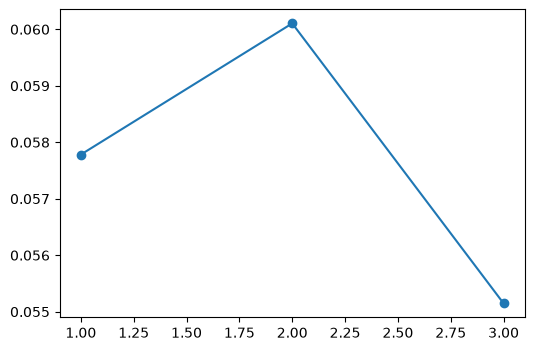

In [ ]:
# 학습 곡선 저장

import matplotlib.pyplot as plt


epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(6, 4))
plt.plot(
    epochs,
    history["train_loss"],
    marker="o",
    label="train_loss",
)
plt.plot(
    epochs,
    history["val_loss"],
    marker="o",
    label="val_loss",
)
plt.xlabel("epoch")
plt.ylabel("loss")
plt.xticks(list(epochs))
plt.legend()
plt.tight_layout()

plot_path = run_dir / "plots" / "loss_curve.png"
plt.savefig(plot_path, dpi=150)
plt.show()
plt.close()

print("plot 저장:", plot_path)